# Analisis Multivariado de Progreso Fisico

Este notebook presenta un caso de analisis estadistico aplicado al seguimiento de una meta fisica. A partir de variables como peso, calorias y pasos, se construye un flujo que combina simulacion, limpieza de datos, analisis descriptivo, deteccion de anomalias y estimacion de tendencia.

## Objetivo del notebook

El objetivo es estimar el comportamiento de un proceso fisico con herramientas de probabilidad multivariada, separando la tendencia real del ruido biologico diario.

En particular, este flujo busca:

- simular datos diarios con variabilidad realista;
- describir cada variable con metricas univariadas;
- identificar y filtrar outliers antes del modelado;
- medir relaciones entre variables mediante covarianza y correlacion;
- detectar comportamientos atipicos con una Gaussiana multivariada;
- estimar el cambio semanal esperado como una referencia de progreso.

> Nota: este ejemplo es pedagogico y sirve para practicar conceptos estadisticos; no reemplaza una evaluacion clinica o deportiva real.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import multivariate_normal, skew, kurtosis
 

## 1. Configuracion y generacion de datos

En esta seccion se construye un conjunto sintetico de 60 dias para representar un escenario de seguimiento fisico.

Las variables simuladas son:

- `Peso_kg`: evoluciona con una tendencia descendente y ruido aleatorio;
- `Calorias`: incorpora asimetria positiva para modelar dias de ingesta elevada;
- `Pasos`: se aproxima con una distribucion normal alrededor de una rutina diaria.

Tambien se agregan algunos outliers de forma intencional para observar como afectan el analisis posterior.

In [11]:
np.random.seed(42)
num_dias = 60  # Simulamos 2 meses de registros

# Generamos variables con comportamientos estadísticos específicos
dias = np.arange(1, num_dias + 1)
# Tendencia bajista en peso con ruido normal
peso = 85 - (dias * 0.12) + np.random.normal(0, 0.4, num_dias)
# Inyectamos Outliers (Lección 1: Outliers y Curtosis)
peso[15] += 3.5 
peso[45] += 2.8

# Calorías con Skewness positiva (días de "cheat meal")
calorias = stats.skewnorm.rvs(a=5, loc=2000, scale=400, size=num_dias)
# Pasos diarios (Distribución normal)
pasos = np.random.normal(8000, 1500, num_dias)

df = pd.DataFrame({
    'Dia': dias,
    'Peso_kg': peso,
    'Calorias': calorias,
    'Pasos': pasos
})

## 2. Analisis univariado

Aqui se estudia cada variable por separado para responder preguntas basicas antes de pasar al modelo conjunto.

Se calculan:

- media y mediana, para ubicar el centro de la distribucion;
- desviacion estandar y varianza, para medir dispersion;
- skewness, para detectar asimetria;
- kurtosis, para evaluar colas pesadas o presencia de valores extremos.

Este paso ayuda a entender si los datos se comportan de forma estable o si requieren limpieza previa.

In [12]:
def reporte_univariado(serie, nombre):
    print(f"\n--- Reporte: {nombre} ---")
    print(f"Media (E[X]): {serie.mean():.2f}")
    print(f"Mediana: {serie.median():.2f}")
    print(f"Desviación Estándar (σ): {serie.std():.2f}")
    print(f"Varianza (σ²): {serie.var():.2f}")
    print(f"Skewness (Asimetría): {skew(serie):.2f}")
    print(f"Kurtosis: {kurtosis(serie):.2f}")

reporte_univariado(df['Peso_kg'], "Peso")
reporte_univariado(df['Calorias'], "Calorías")


--- Reporte: Peso ---
Media (E[X]): 81.38
Mediana: 81.29
Desviación Estándar (σ): 2.21
Varianza (σ²): 4.86
Skewness (Asimetría): 0.20
Kurtosis: -0.93

--- Reporte: Calorías ---
Media (E[X]): 2286.59
Mediana: 2189.83
Desviación Estándar (σ): 271.61
Varianza (σ²): 73774.56
Skewness (Asimetría): 1.14
Kurtosis: 0.64


## 3. Limpieza y estandarizacion

Antes de analizar relaciones multivariadas, conviene reducir el efecto de observaciones demasiado alejadas del patron principal.

Para eso se usa el `Z-score` del peso y se filtran registros con una distancia mayor a dos desviaciones estandar respecto de la media. De esta forma, el modelo posterior se ajusta sobre una base mas estable y representativa.

In [13]:
# Calculamos Z-score para el Peso para limpiar anomalías antes del modelo
df['Z_Peso'] = (df['Peso_kg'] - df['Peso_kg'].mean()) / df['Peso_kg'].std()
# Filtramos registros que están a más de 2 desviaciones estándar
df_limpio = df[np.abs(df['Z_Peso']) < 2].copy()

## 4. Matriz de covarianza y correlacion

En esta parte se analizan las relaciones entre las variables del sistema.

- La **covarianza** muestra si dos variables tienden a moverse juntas.
- La **correlacion** permite comparar esa relacion en una escala normalizada entre `-1` y `1`.

Esta vista es clave para saber si el comportamiento del peso, las calorias y los pasos tiene dependencia estructural o si cada variable actua de manera casi independiente.

In [14]:
# Matriz de Covarianza y Correlación
features = ['Peso_kg', 'Calorias', 'Pasos']
cov_matrix = df_limpio[features].cov()
corr_matrix = df_limpio[features].corr()

print("\n--- Matriz de Covarianza (Σ) ---")
print(cov_matrix)


--- Matriz de Covarianza (Σ) ---
            Peso_kg      Calorias         Pasos
Peso_kg    4.513788     27.673631  1.638009e+01
Calorias  27.673631  74612.319081  8.331009e+03
Pasos     16.380093   8331.008626  2.454008e+06


## 5. Deteccion de anomalias con Gaussiana multivariada

Una vez definidas las relaciones entre variables, se construye una distribucion Gaussiana multivariada para evaluar la probabilidad conjunta de cada dia observado.

La idea es simple: si una combinacion de peso, calorias y pasos tiene una probabilidad demasiado baja respecto del patron general, se marca como comportamiento anomalo.

En este notebook se usa el percentil 5 como umbral para separar dias normales de dias atipicos.

In [15]:
mu = df_limpio[features].mean().values
sigma = df_limpio[features].cov().values
modelo_gaussiano = multivariate_normal(mean=mu, cov=sigma)

# Evaluamos la probabilidad de cada día (incluyendo los outliers originales)
df['Probabilidad_Conjunta'] = modelo_gaussiano.pdf(df[features])
# Si la probabilidad es menor al percentil 5, es un "Comportamiento Extraño"
umbral = np.percentile(df['Probabilidad_Conjunta'], 5)
df['Anomalia_Comportamiento'] = df['Probabilidad_Conjunta'] < umbral

## 6. Prediccion del cambio esperado

Con los datos ya depurados, se estima una tendencia lineal del peso en funcion del tiempo.

El objetivo no es hacer una prediccion exacta de largo plazo, sino obtener una referencia interpretable del ritmo promedio de cambio semanal. Esa estimacion sirve como resumen practico del comportamiento global de la serie.

In [17]:
# Calculamos el Valor Esperado de pérdida semanal basado en los datos limpios
cambio_diario_promedio = np.polyfit(df_limpio['Dia'], df_limpio['Peso_kg'], 1)[0]
esperanza_perdida_semanal = cambio_diario_promedio * 7

print(f"\n--- Predicción ---")
print(f"Valor Esperado de cambio semanal: {esperanza_perdida_semanal:.3f} kg")


--- Predicción ---
Valor Esperado de cambio semanal: -0.826 kg


## 7. Visualizacion e interpretacion

Los graficos finales condensan la historia estadistica del notebook en una sola vista:

- mapa de calor para resumir correlaciones;
- violin plot para observar la forma de la distribucion de calorias;
- QQ-plot para contrastar la normalidad del peso limpio;
- diagrama de dispersion para identificar dias anomalos en el espacio multivariado.

Esta capa visual permite pasar de los numeros a una interpretacion mas intuitiva del problema.

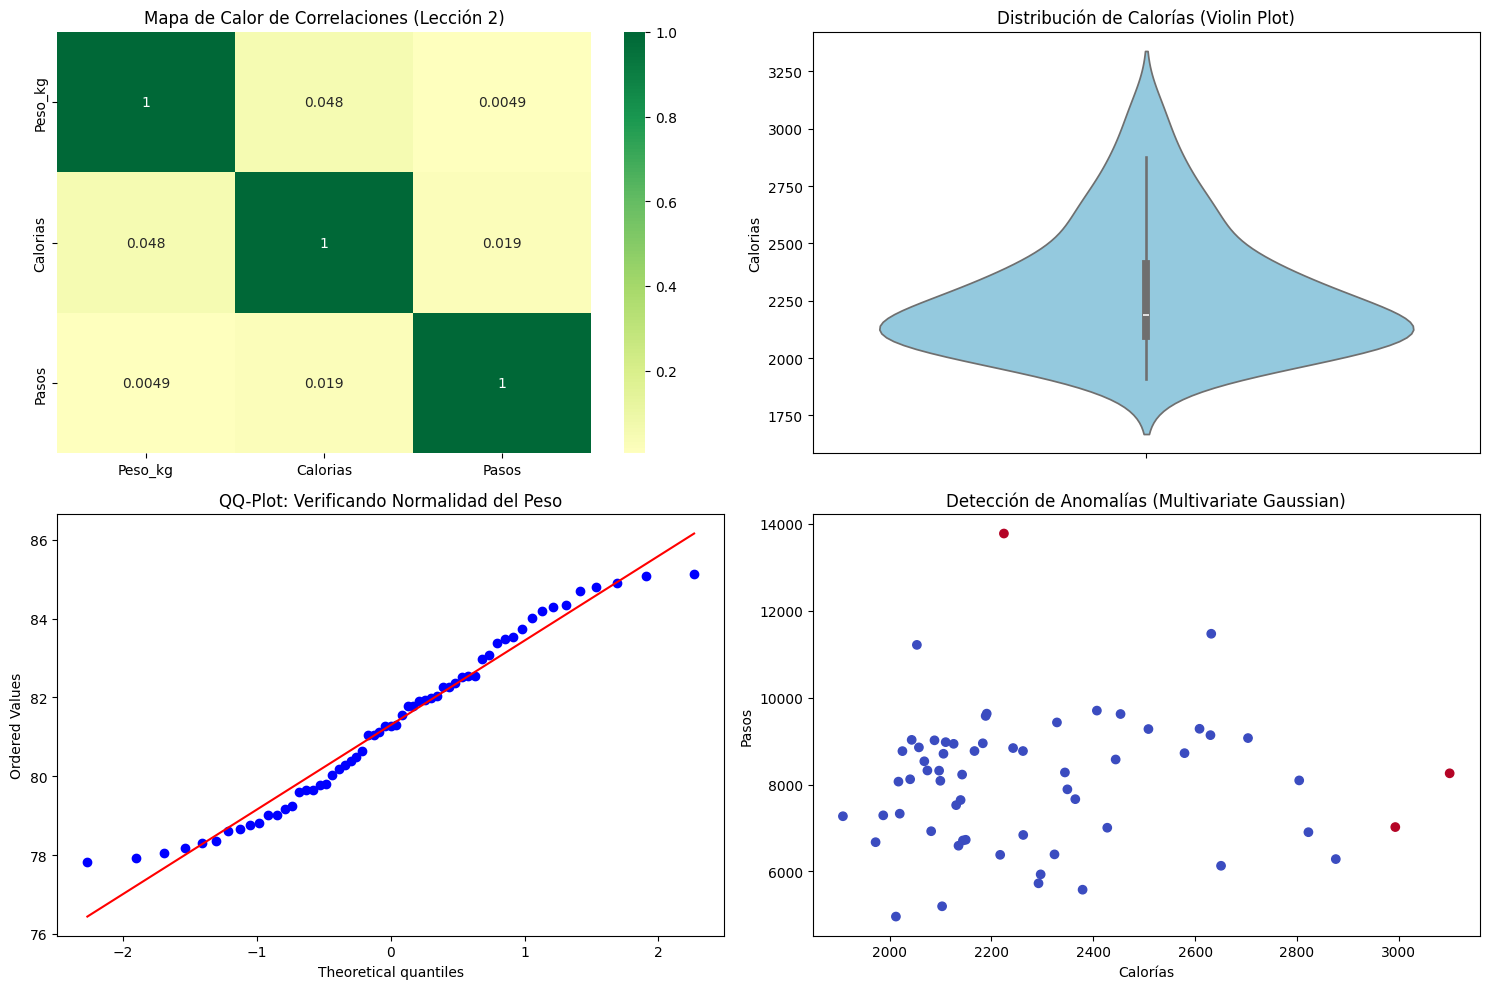

In [18]:
plt.figure(figsize=(15, 10))

# Subplot 1: Matriz de Correlación
plt.subplot(2, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Mapa de Calor de Correlaciones (Lección 2)')

# Subplot 2: Violin Plot de Calorías (Muestra densidad y Skewness)
plt.subplot(2, 2, 2)
sns.violinplot(y=df['Calorias'], color="skyblue")
plt.title('Distribución de Calorías (Violin Plot)')

# Subplot 3: QQ-Plot del Peso (Verificación de Normalidad)
plt.subplot(2, 2, 3)
stats.probplot(df_limpio['Peso_kg'], dist="norm", plot=plt)
plt.title('QQ-Plot: Verificando Normalidad del Peso')

# Subplot 4: Detección de Anomalías Multivariadas
plt.subplot(2, 2, 4)
plt.scatter(df['Calorias'], df['Pasos'], c=df['Anomalia_Comportamiento'], cmap='coolwarm')
plt.title('Detección de Anomalías (Multivariate Gaussian)')
plt.xlabel('Calorías')
plt.ylabel('Pasos')

plt.tight_layout()
plt.show()

## 8. Conclusiones

A partir de este flujo se pueden extraer varias ideas importantes:

- el peso sigue una tendencia general descendente, pero con dias puntuales de desviacion;
- las calorias muestran una distribucion mas asimetrica que el resto de variables;
- la limpieza previa mejora la estabilidad del analisis multivariado;
- una anomalia estadistica no implica automaticamente un error, sino un dia poco habitual dentro del patron conjunto.

En conjunto, el notebook queda organizado como un mini informe exploratorio: describe, limpia, relaciona, detecta y resume.